Load and explore the data


In [46]:
import sklearn, numpy, pandas, matplotlib
print("scikit-learn", sklearn.__version__)
print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("matplotlib", matplotlib.__version__)

scikit-learn 1.6.1
numpy 2.0.2
pandas 2.3.3
matplotlib 3.10.0


In [34]:
import os
DATA = ("/kaggle/input/datasets/sajaahamasha/freightdata"
        if os.path.exists("/kaggle/input") else "data")

In [35]:
import numpy as np
import pandas as pd

for f in sorted(os.listdir(DATA)):
    print(f)

train = pd.read_csv(f"{DATA}/train-test.csv", parse_dates=["date"])
val = pd.read_csv(f"{DATA}/validation.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print()
print("Train dates:", train.date.min().date(), "->", train.date.max().date())
print("Validation dates:", val.date.min().date(), "->", val.date.max().date())
print()
print("Columns in train but not in validation:", set(train.columns) - set(val.columns))
print()
print("Missing values in train:")
print(train.isna().sum()[train.isna().sum() > 0])
print()
print("Missing values in validation:")
print(val.isna().sum()[val.isna().sum() > 0])

train.head()

december-chart-inputs.csv
score.py
train-test.csv
validation-predictions-template.csv
validation.csv
Train shape: (48000, 14)
Validation shape: (12000, 13)

Train dates: 2025-01-01 -> 2025-10-31
Validation dates: 2025-11-01 -> 2025-12-31

Columns in train but not in validation: {'posted_rate'}

Missing values in train:
weight          300
market_index    374
dtype: int64

Missing values in validation:
weight          165
market_index    249
dtype: int64


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


Data-quality checks

In [36]:
neg = train[train.weight < 0]
print("Negative weights:", len(neg))
print("Min weight:", train.weight.min(), "| Max weight:", train.weight.max())
print("Loads at exactly the max weight:", (train.weight == train.weight.max()).sum())
print()

train["rpm"] = train.posted_rate / train.distance
lane_median = train.groupby(["pickup", "delivery", "equipment"])["rpm"].transform("median")
train["rel"] = train.rpm / lane_median   # 1.0 = normal price for this lane

print("Rate vs lane median, percentiles:")
print(train.rel.quantile([0.001, 0.005, 0.01, 0.5, 0.99, 0.995, 0.999]).round(2))
print()
bad = (train.rel < 0.6) | (train.rel > 1.6)
print("Suspicious rates (below 0.6x or above 1.6x):", bad.sum())
print(train.loc[bad, ["pickup", "delivery", "distance", "equipment", "posted_rate", "rel"]].head(8))
print()

print("Duplicate load_ids:", train.load_id.duplicated().sum())
print("Duplicate rows (ignoring id):", train.drop(columns="load_id").duplicated().sum())
print()

new_cities = (set(val.pickup) | set(val.delivery)) - (set(train.pickup) | set(train.delivery))
print("Cities only in validation:", new_cities)

Negative weights: 292
Min weight: -47500.0 | Max weight: 47500.0
Loads at exactly the max weight: 1191

Rate vs lane median, percentiles:
0.001    0.20
0.005    0.36
0.010    0.89
0.500    1.00
0.990    1.12
0.995    2.70
0.999    4.48
Name: rel, dtype: float64

Suspicious rates (below 0.6x or above 1.6x): 665
          pickup      delivery  distance equipment  posted_rate       rel
50   Los Angeles     Green Bay    2202.5    Reefer      1243.45  0.283368
190        Tampa     Milwaukee     919.8   Dry Van       704.89  0.380843
294   Greensboro      Syracuse     685.6   Dry Van       518.31  0.366303
439     Richmond    Charleston     394.9   Dry Van       276.27  0.312178
469      Phoenix  Jacksonville    2154.3   Dry Van     10854.69  2.622431
508    Las Vegas  Grand Rapids    1976.4   Flatbed       699.41  0.312492
785  Kansas City    Charleston     861.5   Dry Van      4587.83  2.521870
868  Albuquerque     Milwaukee    1373.5   Flatbed      2700.52  0.331226

Duplicate load_ids: 0

Cleaning

In [37]:
within_day_std = train.groupby("date")["market_index"].std().mean()
overall_std = train["market_index"].std()
print(f"market_index std within a day: {within_day_std:.3f}  |  overall: {overall_std:.3f}")
print()


def clean_features(df):
    out = df.copy()
    out["weight"] = out["weight"].abs()
    day_mean = out.groupby("date")["market_index"].transform("mean")
    out["market_index"] = out["market_index"].fillna(day_mean)
    return out


train_clean = clean_features(train)
val_clean = clean_features(val)
train_clean = train_clean[~bad].copy()

print("Train rows after cleaning:", len(train_clean), f"(dropped {bad.sum()})")
print("Negative weights left:", (train_clean.weight < 0).sum(), "|", (val_clean.weight < 0).sum())
print("Missing market_index left:", train_clean.market_index.isna().sum(), "|", val_clean.market_index.isna().sum())
print("Missing weight left (kept on purpose):", train_clean.weight.isna().sum(), "|", val_clean.weight.isna().sum())

market_index std within a day: 0.025  |  overall: 0.168

Train rows after cleaning: 47335 (dropped 665)
Negative weights left: 0 | 0
Missing market_index left: 0 | 0
Missing weight left (kept on purpose): 297 | 165


What drives the rate

Rate per mile by equipment:
equipment
Dry Van    2.046
Flatbed    2.220
Reefer     2.312
Name: rpm, dtype: float64

Rate vs lane normal, by weight group:
weight
(4999.999, 24598.4]    0.973
(24598.4, 29390.0]     0.987
(29390.0, 33611.0]     1.002
(33611.0, 38415.2]     1.015
(38415.2, 47500.0]     1.024
Name: rel, dtype: float64

By month:
      rate_level  market_index  quote_signal
date                                        
1          0.961         0.926         2.068
2          0.971         0.996         2.096
3          0.996         1.073         2.180
4          1.001         1.207         1.965
5          1.019         1.301         1.913
6          1.036         1.280         2.297
7          1.014         1.201         1.923
8          0.992         0.981         2.053
9          1.004         0.893         2.200
10         1.006         0.957         1.943

By day of week (0=Mon):
date
0    0.9936
1    0.9993
2    1.0057
3    1.0088
4    1.0048
5    0.9974
6    0.9917
Nam

/tmp/ipykernel_58/2438602665.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tc.groupby(pd.qcut(tc.weight, 5))["rel"].mean().round(3))


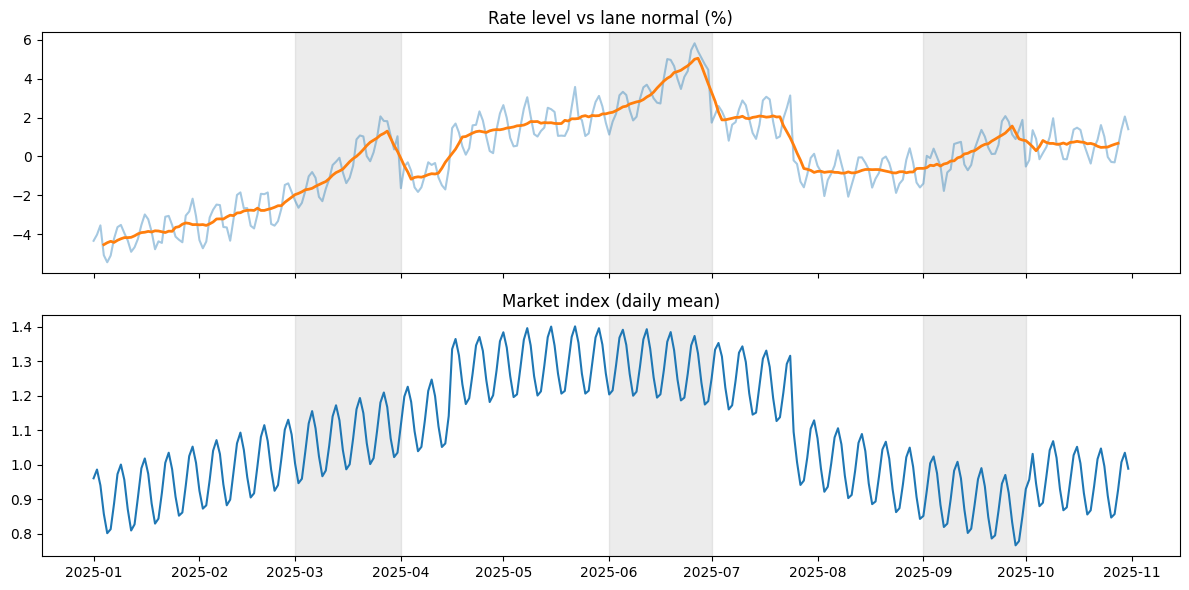

In [38]:
import matplotlib.pyplot as plt

tc = train_clean
print("Rate per mile by equipment:")
print(tc.groupby("equipment")["rpm"].median().round(3))
print()

print("Rate vs lane normal, by weight group:")
print(tc.groupby(pd.qcut(tc.weight, 5))["rel"].mean().round(3))
print()

monthly = tc.groupby(tc.date.dt.month).agg(rate_level=("rel", "mean"),
                                           market_index=("market_index", "mean"),
                                           quote_signal=("quote_signal", "mean"))
print("By month:")
print(monthly.round(3))
print()

print("By day of week (0=Mon):")
print(tc.groupby(tc.date.dt.dayofweek)["rel"].mean().round(4))
daily = tc.groupby("date").agg(rate_level=("rel", "mean"), market_index=("market_index", "mean"))
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
a1.plot(daily.index, (daily.rate_level - 1) * 100, alpha=0.4)
a1.plot(daily.index, (daily.rate_level.rolling(7, center=True).mean() - 1) * 100, lw=2)
a1.set_title("Rate level vs lane normal (%)")
a2.plot(daily.index, daily.market_index)
a2.set_title("Market index (daily mean)")
for ax in (a1, a2):
    for m in (3, 6, 9): 
        ax.axvspan(pd.Timestamp(2025, m, 1), pd.Timestamp(2025, m + 1, 1), color="grey", alpha=0.15)
plt.tight_layout()
plt.show()

Validation design: rolling-origin, two-month horizon

In [39]:
FOLDS = [("2025-07-01", "2025-09-01"),
         ("2025-08-01", "2025-10-01"),
         ("2025-09-01", "2025-11-01")]


def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.mean(np.abs(y_pred - y_true) / y_true) * 100


def evaluate(fit_predict, data=tc):
    scores = []
    for train_end, test_end in FOLDS:
        tr = data[data.date < train_end]
        te = data[(data.date >= train_end) & (data.date < test_end)]
        scores.append(mape(te.posted_rate, fit_predict(tr, te)))
    print("Folds:", [round(s, 2) for s in scores], "| Mean MAPE:", round(np.mean(scores), 2), "%")
    return np.mean(scores)

def lane_median_baseline(tr, te):
    lane = tr.groupby(["pickup", "delivery", "equipment"])["rpm"].median()
    equip = tr.groupby("equipment")["rpm"].median()    
    keys = pd.MultiIndex.from_frame(te[["pickup", "delivery", "equipment"]])
    rpm = lane.reindex(keys).to_numpy()
    rpm = np.where(np.isnan(rpm), te.equipment.map(equip).to_numpy(), rpm)
    return rpm * te.distance.to_numpy()


print("Lane median baseline:")
evaluate(lane_median_baseline)

Lane median baseline:
Folds: [np.float64(4.36), np.float64(3.98), np.float64(3.81)] | Mean MAPE: 4.05 %


np.float64(4.050260876731377)

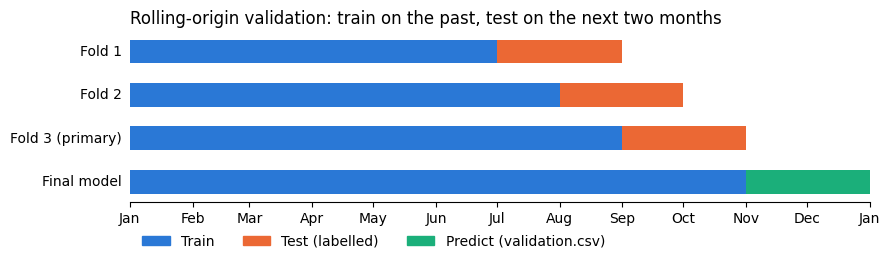

In [49]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch

rows = [("Fold 1", *FOLDS[0]), ("Fold 2", *FOLDS[1]), ("Fold 3 (primary)", *FOLDS[2]),
        ("Final model", "2025-11-01", "2026-01-01")]
start = pd.Timestamp("2025-01-01")

fig, ax = plt.subplots(figsize=(9, 2.8))
for i, (name, cut, end) in enumerate(rows):
    y = len(rows) - 1 - i
    cut, end = pd.Timestamp(cut), pd.Timestamp(end)
    test_color = "#1baf7a" if name == "Final model" else "#eb6834"
    ax.barh(y, (cut - start).days, left=start, height=0.55, color="#2a78d6")
    ax.barh(y, (end - cut).days, left=cut, height=0.55, color=test_color)
    ax.text(start - pd.Timedelta(days=4), y, name, ha="right", va="center")

ax.set_yticks([])
ax.set_xlim(start, pd.Timestamp("2026-01-01"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.set_title("Rolling-origin validation: train on the past, test on the next two months", loc="left")
ax.legend(handles=[Patch(color="#2a78d6", label="Train"),
                   Patch(color="#eb6834", label="Test (labelled)"),
                   Patch(color="#1baf7a", label="Predict (validation.csv)")],
          frameon=False, ncol=3, loc="upper left", bbox_to_anchor=(0, -0.12))
plt.tight_layout()
plt.savefig("validation_split.png", dpi=200, bbox_inches="tight")
plt.show()

Gradient boosting, and why a random split misleads

In [40]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split

EQUIP = {"Dry Van": 0, "Reefer": 1, "Flatbed": 2}


def load_features(df):
    return pd.DataFrame({
        "distance": df.distance, "weight": df.weight,
        "pickup_lat": df.pickup_lat, "pickup_lon": df.pickup_lon,
        "delivery_lat": df.delivery_lat, "delivery_lon": df.delivery_lon,
        "equipment": df.equipment.map(EQUIP),
    })


def time_features(df):
    X = load_features(df)
    X["market_index"] = df.market_index
    X["quote_signal"] = df.quote_signal
    X["day_of_week"] = df.date.dt.dayofweek
    X["day_of_year"] = df.date.dt.dayofyear
    return X


def make_gbm(make_X):
    def fit_predict(tr, te):
        model = HistGradientBoostingRegressor(
            max_iter=600, learning_rate=0.06, max_leaf_nodes=63, min_samples_leaf=40,
            l2_regularization=1.0, categorical_features=[6], random_state=0)
        model.fit(make_X(tr), np.log(tr.rpm))
        return np.exp(model.predict(make_X(te))) * te.distance.to_numpy()
    return fit_predict


print("A) GBM, load features only:")
evaluate(make_gbm(load_features))

print("\nB) GBM + time/market features (forward folds):")
evaluate(make_gbm(time_features))

print("\nB) same model, RANDOM 80/20 split:")
tr, te = train_test_split(tc, test_size=0.2, random_state=0)
print("MAPE:", round(mape(te.posted_rate, make_gbm(time_features)(tr, te)), 2), "%")

A) GBM, load features only:
Folds: [np.float64(2.44), np.float64(2.05), np.float64(2.05)] | Mean MAPE: 2.18 %

B) GBM + time/market features (forward folds):
Folds: [np.float64(4.4), np.float64(3.8), np.float64(2.14)] | Mean MAPE: 3.45 %

B) same model, RANDOM 80/20 split:
MAPE: 1.38 %


Hybrid model

In [41]:
from sklearn.linear_model import LinearRegression

T0 = pd.Timestamp("2025-01-01")


def market_features(df, terms):
    d = df.date
    qe = (d.dt.month % 3 == 0).astype(float)         
    cols = {
        "market_index": df.market_index,
        "trend": (d - T0).dt.days / 30.44,            
        "quarter_end": qe,
        "quarter_end_ramp": qe * (d.dt.day - 1) / (d.dt.days_in_month - 1),
        "qs_quarter_end": (df.quote_signal - 2.05) * qe,
    }
    out = [np.asarray(cols[t], float) for t in terms if t != "day_of_week"]
    if "day_of_week" in terms:
        out += [(d.dt.dayofweek == k).astype(float).to_numpy() for k in range(1, 7)]
    return np.column_stack(out)


class HybridModel:
    def __init__(self, terms, rounds=3):
        self.terms, self.rounds = terms, rounds

    def fit(self, df):
        y = np.log(df.rpm.to_numpy())
        X_load, X_mkt = load_features(df), market_features(df, self.terms)
        self.lin = LinearRegression().fit(X_mkt, y)
        for _ in range(self.rounds):                   
            self.gbm = HistGradientBoostingRegressor(
                max_iter=600, learning_rate=0.06, max_leaf_nodes=63, min_samples_leaf=40,
                l2_regularization=1.0, categorical_features=[6], random_state=0
            ).fit(X_load, y - self.lin.predict(X_mkt))
            self.lin = LinearRegression().fit(X_mkt, y - self.gbm.predict(X_load))
        return self

    def predict(self, df):
        log_rpm = self.gbm.predict(load_features(df)) + self.lin.predict(market_features(df, self.terms))
        return np.exp(log_rpm) * df.distance.to_numpy()


def make_hybrid(terms):
    return lambda tr, te: HybridModel(terms).fit(tr).predict(te)


ladder = {
    "+ market_index":           ["market_index"],
    "+ trend":                  ["market_index", "trend"],
    "+ quarter_end":            ["market_index", "trend", "quarter_end"],
    "+ ramp, quote, weekday":   ["market_index", "trend", "quarter_end", "quarter_end_ramp",
                                 "qs_quarter_end", "day_of_week"],
}
for name, terms in ladder.items():
    print(f"\nHybrid {name}:")
    evaluate(make_hybrid(terms))


Hybrid + market_index:
Folds: [np.float64(2.3), np.float64(4.01), np.float64(4.45)] | Mean MAPE: 3.59 %

Hybrid + trend:
Folds: [np.float64(4.44), np.float64(2.07), np.float64(2.09)] | Mean MAPE: 2.87 %

Hybrid + quarter_end:
Folds: [np.float64(2.39), np.float64(1.97), np.float64(1.9)] | Mean MAPE: 2.09 %

Hybrid + ramp, quote, weekday:
Folds: [np.float64(1.77), np.float64(1.64), np.float64(1.75)] | Mean MAPE: 1.72 %


Honest evaluation and second-pass cleaning

In [42]:
def flag_outliers(df):
    rpm = df.posted_rate / df.distance
    med = rpm.groupby([df.pickup, df.delivery, df.equipment]).transform("median")
    rel = rpm / med
    return (rel < 0.6) | (rel > 1.6)


class RobustHybrid(HybridModel):
    def fit(self, df, threshold=0.15):
        super().fit(df)
        resid = np.log(df.posted_rate.to_numpy()) - np.log(self.predict(df))
        keep = np.abs(resid) <= threshold
        self.n_dropped = int((~keep).sum())
        return super().fit(df[keep])


all_rows = clean_features(train)  


def evaluate_honest(model_class, terms):
    scores = []
    for train_end, test_end in FOLDS:
        tr = all_rows[all_rows.date < train_end]
        tr = tr[~flag_outliers(tr)]                   
        te = all_rows[(all_rows.date >= train_end) & (all_rows.date < test_end)]
        te = te[~bad.loc[te.index]]                    
        pred = model_class(terms).fit(tr).predict(te)
        scores.append(mape(te.posted_rate, pred))
    print("Folds:", [round(float(s), 2) for s in scores], "| Mean MAPE:", round(float(np.mean(scores)), 2), "%")


FINAL_TERMS = ["market_index", "trend", "quarter_end", "quarter_end_ramp", "qs_quarter_end", "day_of_week"]

print("Hybrid, honest per-fold cleaning:")
evaluate_honest(HybridModel, FINAL_TERMS)

print("\nHybrid + second-pass cleaning (FINAL MODEL):")
evaluate_honest(RobustHybrid, FINAL_TERMS)

Hybrid, honest per-fold cleaning:
Folds: [1.87, 1.7, 1.81] | Mean MAPE: 1.79 %

Hybrid + second-pass cleaning (FINAL MODEL):
Folds: [1.63, 1.5, 1.66] | Mean MAPE: 1.6 %


 Final model and predictions

In [43]:
import os

OUT = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
final_train = all_rows[~flag_outliers(all_rows)]
final_model = RobustHybrid(FINAL_TERMS).fit(final_train)
print("Training rows:", len(final_train), "| second-pass dropped:", final_model.n_dropped)
print("Linear coefficients:", dict(zip(FINAL_TERMS[:5], final_model.lin.coef_[:5].round(4))))

template = pd.read_csv(f"{DATA}/validation-predictions-template.csv")
pred = pd.Series(final_model.predict(val_clean), index=val_clean.load_id)
template["predicted_rate"] = template.load_id.map(pred).round(2)
assert template.predicted_rate.notna().all() and (template.predicted_rate > 0).all()
template.to_csv(f"{OUT}/validation_predictions.csv", index=False)
print("\nValidation predictions:", len(template))
print(template.predicted_rate.describe().round(1))

dec_raw = pd.read_csv(f"{DATA}/december-chart-inputs.csv")
dec = dec_raw.copy()
dec["date"] = pd.to_datetime(dec.date)

coords = pd.concat([
    df[[f"{s}", f"{s}_lat", f"{s}_lon"]].set_axis(["city", "lat", "lon"], axis=1)
    for df in (train, val) for s in ("pickup", "delivery")
]).groupby("city")[["lat", "lon"]].median()
for s in ("pickup", "delivery"):
    dec[f"{s}_lat"] = dec[s].map(coords.lat)
    dec[f"{s}_lon"] = dec[s].map(coords.lon)

daily_market = val_clean.groupby("date")[["market_index", "quote_signal"]].mean()
dec = dec.join(daily_market, on="date")
assert dec.isna().sum().drop("predicted_rate").sum() == 0

dec_raw["predicted_rate"] = final_model.predict(dec).round(2)
dec_raw.to_csv(f"{OUT}/december_chart_inputs.csv", index=False)
print("\nDecember predictions:", dec_raw.predicted_rate.min(), "->", dec_raw.predicted_rate.max())

Training rows: 47335 | second-pass dropped: 43
Linear coefficients: {'market_index': np.float64(0.1426), 'trend': np.float64(0.006), 'quarter_end': np.float64(-0.006), 'quarter_end_ramp': np.float64(0.0348), 'qs_quarter_end': np.float64(0.0463)}

Validation predictions: 12000
count    12000.0
mean      2393.4
std       1387.7
min        183.9
25%       1286.2
50%       2068.5
75%       3405.2
max       6946.4
Name: predicted_rate, dtype: float64

December predictions: 823.35 -> 875.75


 Official scorer

/kaggle/working
Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


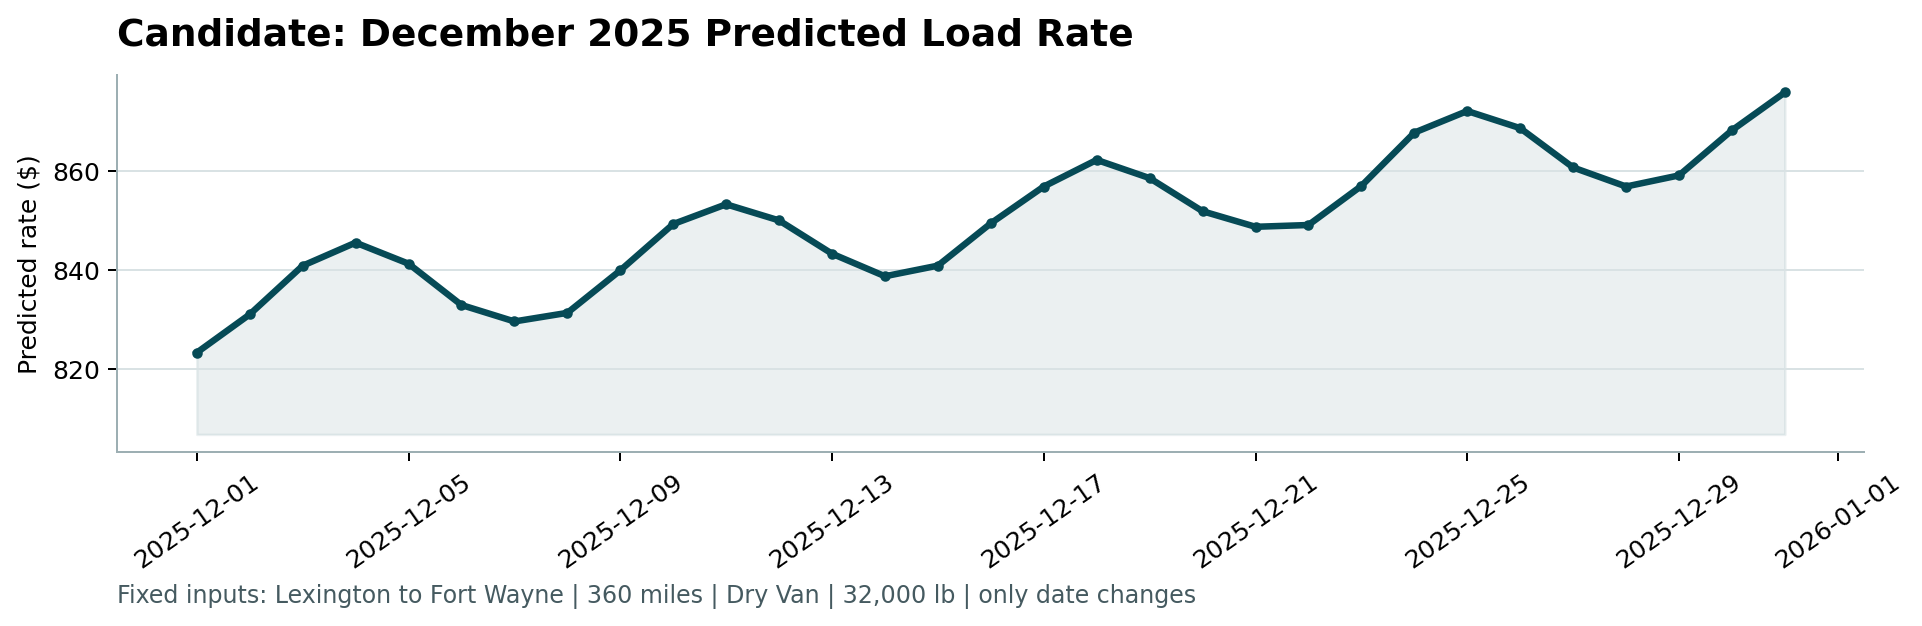

In [44]:
%cd {OUT}
!python {DATA}/score.py --predictions validation_predictions.csv --december-predictions december_chart_inputs.csv

from IPython.display import Image
Image("scorer_results/candidate_december.png")

Final model comparison (honest evaluation, all models)

In [45]:
def evaluate_fp(fit_predict):
    scores = []
    for train_end, test_end in FOLDS:
        tr = all_rows[all_rows.date < train_end]
        tr = tr[~flag_outliers(tr)]
        te = all_rows[(all_rows.date >= train_end) & (all_rows.date < test_end)]
        te = te[~bad.loc[te.index]]
        scores.append(float(mape(te.posted_rate, fit_predict(tr, te))))
    return scores


candidates = {
    "Lane median baseline":                 lane_median_baseline,
    "GBM, load features only":              make_gbm(load_features),
    "GBM + time/market (unconstrained)":    make_gbm(time_features),
    "Hybrid: market_index":                 make_hybrid(["market_index"]),
    "Hybrid: + trend":                      make_hybrid(["market_index", "trend"]),
    "Hybrid: + quarter_end":                make_hybrid(["market_index", "trend", "quarter_end"]),
    "Hybrid: + ramp, quote, weekday":       make_hybrid(FINAL_TERMS),
    "FINAL: hybrid + 2nd-pass cleaning":    lambda tr, te: RobustHybrid(FINAL_TERMS).fit(tr).predict(te),
}

rows = []
for name, fp in candidates.items():
    s = evaluate_fp(fp)
    rows.append({"model": name, "fold1": s[0], "fold2": s[1], "fold3": s[2], "mean_MAPE": np.mean(s)})
    print(f"{name:40s} {[round(x, 2) for x in s]}  mean {np.mean(s):.2f}%")

comparison = pd.DataFrame(rows).round(3)
comparison.to_csv(f"{OUT}/model_comparison.csv", index=False)
comparison

Lane median baseline                     [5.19, 4.69, 4.2]  mean 4.69%
GBM, load features only                  [2.48, 2.1, 2.07]  mean 2.22%
GBM + time/market (unconstrained)        [4.32, 3.77, 2.16]  mean 3.42%
Hybrid: market_index                     [2.3, 3.98, 4.46]  mean 3.58%
Hybrid: + trend                          [4.63, 2.12, 2.15]  mean 2.97%
Hybrid: + quarter_end                    [2.59, 2.04, 1.94]  mean 2.19%
Hybrid: + ramp, quote, weekday           [1.87, 1.7, 1.81]  mean 1.79%
FINAL: hybrid + 2nd-pass cleaning        [1.63, 1.5, 1.66]  mean 1.60%


,model,fold1,fold2,fold3,mean_MAPE
0,Lane median baseline,5.189,4.693,4.200,4.694
1,"GBM, load features only",2.480,2.100,2.075,2.219
2,GBM + time/market (unconstrained),4.318,3.773,2.161,3.417
3,Hybrid: market_index,2.297,3.982,4.456,3.578
4,Hybrid: + trend,4.633,2.116,2.148,2.966
5,Hybrid: + quarter_end,2.593,2.037,1.939,2.190
6,"Hybrid: + ramp, quote, weekday",1.872,1.699,1.812,1.795
7,FINAL: hybrid + 2nd-pass cleaning,1.632,1.503,1.662,1.599


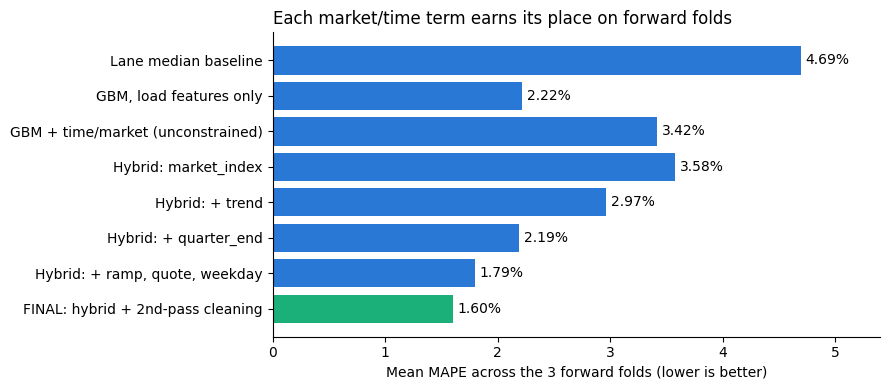

In [47]:
import matplotlib.pyplot as plt

df = comparison.iloc[::-1]
colors = ["#1baf7a" if m.startswith("FINAL") else "#2a78d6" for m in df.model]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(df.model, df.mean_MAPE, color=colors)
for y, v in enumerate(df.mean_MAPE):
    ax.text(v + 0.04, y, f"{v:.2f}%", va="center")
ax.set_xlabel("Mean MAPE across the 3 forward folds (lower is better)")
ax.set_title("Each market/time term earns its place on forward folds", loc="left")
ax.set_xlim(0, df.mean_MAPE.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT}/model_comparison.png", dpi=200)
plt.show()